In [17]:
# исследование свойств
# простых чисел и их
# распределений на скатерти Улама

# Ячейка № 1

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки numpy
import numpy as np

# импорт из библиотеки scipy.optimize
# функции curve_fit
from scipy.optimize import curve_fit

In [18]:
# Ячейка № 2

# задание функции, возвращающей
# массив, содержащий простые числа из
# диапазона [2,N], и нули
# вместо составных чисел
def Eratosphen(N):
    # инициализация массива,
    # используемого для хранения простых чисел
    # и нулей вместо составных чисел
    Prime = np.linspace(2, N, N - 1, dtype=int)

    # реализация алгоритма Эратосфена
    m = 2
    while m <= N:
        j = m * 2
        while j < N + 1:
            Prime[j - 2] = 0
            j = j + m
        m = m + 1

    return Prime


In [19]:
# Ячейка № 3

# задание функции,
# возвращающей массив
# простых чисел, находящихся
# в диапазоне [2,N]
# (аналог процедуры вычеркивания
# простых чисел,
# реализованной Уламом)
def Eratosphen_out_Zeros(N):
    # вызов функции Prime
    Prime = Eratosphen(N)
    N = len(Prime)

    # инициализация пустого массива,
    # используемого далее для размещения
    # простых чисел
    Z = np.array([], dtype=int)
    Flag = 0

    # перемещение простых чисел
    # из массива Prime
    # в массив Z
    for i in range(N):
        if not (Prime[i] == 0):
            if Flag == 0:
                Z = Prime[i]
                Flag = 1
            else:
                Z = np.hstack((Z, Prime[i]))

    return Z

In [20]:
# Ячейка № 4

# нахождение простых чисел,
# находящихся в диапазоне [2,100]
Q = Eratosphen_out_Zeros(100)

print(Q)

[ 2  3  5  7 11 13 17 19 23 29 31 37 41 43 47 53 59 61 67 71 73 79 83 89
 97]


In [21]:
# Ячейка № 5

# задание функции, возвращающей
# значения Pi-функции
def Pi_Function(N):
    # вычисление значений простых чисел,
    # находящихся в диапазоне [2,N]
    Z = Eratosphen_out_Zeros(N)

    # вычисление значений Pi-функции
    Length_Z = len(Z)
    Value_of_Pi = np.zeros(N)
    Value_of_Pi = Value_of_Pi.astype(int)
    j = 0
    for i in range(N):
        # j = 0
        while (j <= Length_Z - 1) and (Z[j] <= i):
            j = j + 1
        Value_of_Pi[i] = j

    return Value_of_Pi


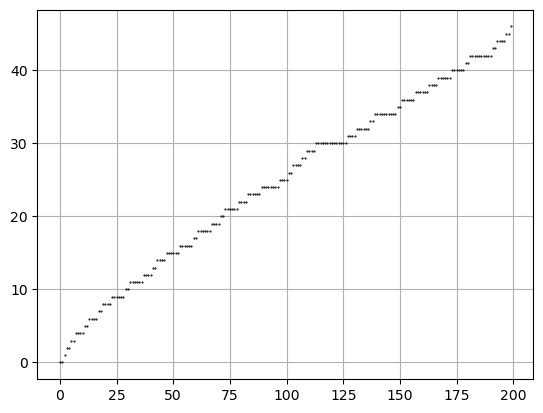

In [ ]:
# Ячейка № 5

# визуализация значений pi-функции,
# значения аргументов которой
# простые числа, находящиеся в
# диапазоне [2,N]

plt.plot(Pi_Function(200), ".k", markersize=1.0)
plt.grid(True)

plt.show()


In [23]:
# Ячейка № 6

# задание функции, возвращающей
# значения интегрального логарифма
def Li(N):
    x = np.linspace(2, N + 1, N)
    z = 1 / np.log(x)
    Z = np.cumsum(z)

    return Z

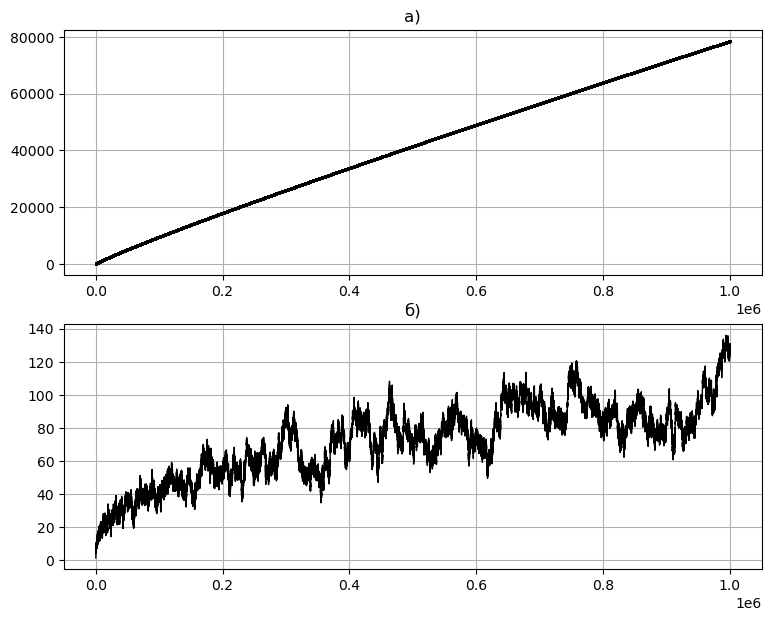

In [ ]:
# Ячейка № 7

# визуализация графика
#  Li-функции и
# разностей Li-функция - Pi-функция

N = 10**6
# вычисление значений Li-функции
Q = Li(N)

# вычисление значений Pi-функции
V_Pi = Pi_Function(N)

# визуализация результатов расчетов
fig = plt.figure(figsize=(9, 7))

# визуализация графика
#  Li-функции
ax = plt.subplot(2, 1, 1)
plt.plot(V_Pi, ".k", markersize=1)
plt.grid(True)  # визуализация pi-функции
plt.title("а)")

# визуализация зависимости разностей
# Li-функция - Pi-функция от
#  порядкового гномера простого числа
ax = plt.subplot(2, 1, 2)
plt.plot(Q - V_Pi, "-k", lw=1)
plt.grid(True)  # визуализация pi-функции
plt.title("б)")

plt.show()

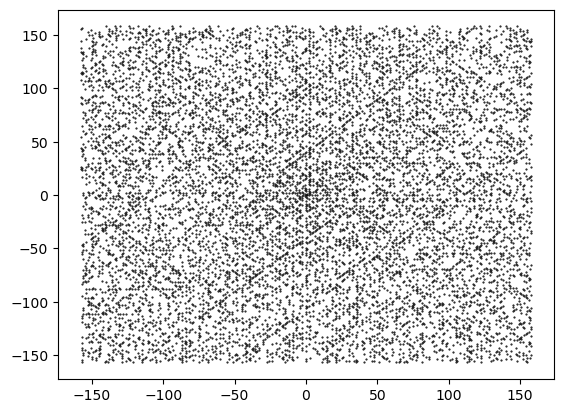

In [25]:
# Ячейка № 8

# визуализация скатерти Улама
# в полярной системе координат

# задание значения правой границы
# интервала поиска простых чисел
N = 10**5

# вычисление массива, содержащего
# последовательные простые числа и нули
# вместо составных чисел
Z = Eratosphen(N + 1)

# задание массива векторов, определяющих
# данного простого числа на скатерти Улама
dr = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]])

# визуализация скатерти Улама
# в декартовой системе координат
dK = 0
x = 0
y = 0

plt.plot(x, y, ".k", markersize=1)

N_Right = 1
N_Up = 1
N_Left = 2
N_Down = 2

m = 1

while m <= len(Z) - 1:
    # print(m)
    N_R = 1
    while (m <= N - 1) and (N_R <= N_Right):
        N_R = N_R + 1
        x = x + dr[0][0]
        y = y + dr[0][1]
        if m + 1 == Z[m - 1]:
            plt.plot(x, y, ".k", markersize=1)
        m = m + 1

    N_U = 1
    while (m <= N - 1) and (N_U <= N_Up):
        N_U = N_U + 1
        x = x + dr[1][0]
        y = y + dr[1][1]
        if m + 1 == Z[m - 1]:
            plt.plot(x, y, ".k", markersize=1)
        m = m + 1

    N_L = 1
    while (m <= N - 1) and (N_L <= N_Left):
        N_L = N_L + 1
        x = x + dr[2][0]
        y = y + dr[2][1]
        if m + 1 == Z[m - 1]:
            plt.plot(x, y, ".k", markersize=1)
        m = m + 1

    N_D = 1
    while (m <= N - 1) and (N_D <= N_Down):
        N_D = N_D + 1
        x = x + dr[3][0]
        y = y + dr[3][1]
        if m + 1 == Z[m - 1]:
            plt.plot(x, y, ".k", markersize=1)
        m = m + 1

    N_Right = N_Right + 2
    N_Up = N_Up + 2
    N_Left = N_Left + 2
    N_Down = N_Down + 2

plt.show()

In [26]:
# Ячейка № 9

# задание функции, возвращающей
# изображение скатерти Улама
# в полярной системе координат
def Ulam_Polar(N):
    # вызов функции Eratosphen_out_Zeros
    Z = Eratosphen_out_Zeros(N + 1)

    m = np.linspace(1, len(Z), len(Z))
    # вычисление значений полярных координат
    # данного простого числа
    x = Z * np.cos(m)
    y = Z * np.sin(m)
    F = plt.figure(figsize=(8, 8))
    # Create a figure and axi
    F.add_subplot()
    plt.plot(x / N, y / N, ".k", markersize=1)

    return F

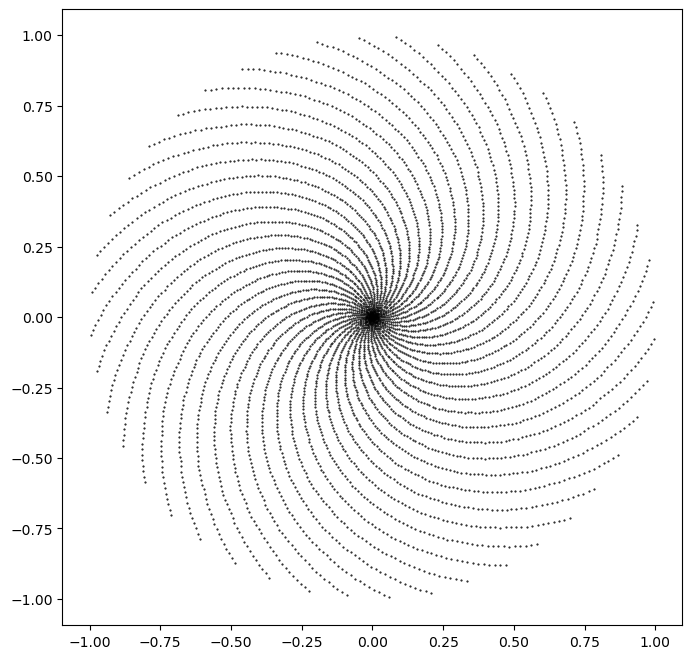

In [27]:
# Ячейка № 10

# визуализация спирали Улама
# в полярной системе координат
N = 5 * 10**4
F = Ulam_Polar(N)

In [28]:
# Ячейка № 11

# задание функции,
# возвращающей значения
# простых чисел с заданным шагом
def Prime_Select(Z, m):
    Z_Select = np.array([], dtype=int)
    k = 0
    i = 1
    k = m - 1
    while k <= len(Z) - 1:
        Z_Select = np.hstack((Z_Select, Z[k]))
        k = m - 1 + 44 * i
        i = i + 1

    return Z_Select

In [29]:
# Ячейка № 12
k = 1
for m in range(1, 50):
    Z1 = Prime_Select(Z, m)
    print(
        "Простое число № ",
        m,
        " Значение простого числа ",
        Z[m - 1],
        "  P-спираль № ",
        k,
    )
    k = k + 1
    if k > 44:
        k = 1

Простое число №  1  Значение простого числа  2   P-спираль №  1
Простое число №  2  Значение простого числа  3   P-спираль №  2
Простое число №  3  Значение простого числа  0   P-спираль №  3
Простое число №  4  Значение простого числа  5   P-спираль №  4
Простое число №  5  Значение простого числа  0   P-спираль №  5
Простое число №  6  Значение простого числа  7   P-спираль №  6
Простое число №  7  Значение простого числа  0   P-спираль №  7
Простое число №  8  Значение простого числа  0   P-спираль №  8
Простое число №  9  Значение простого числа  0   P-спираль №  9
Простое число №  10  Значение простого числа  11   P-спираль №  10
Простое число №  11  Значение простого числа  0   P-спираль №  11
Простое число №  12  Значение простого числа  13   P-спираль №  12
Простое число №  13  Значение простого числа  0   P-спираль №  13
Простое число №  14  Значение простого числа  0   P-спираль №  14
Простое число №  15  Значение простого числа  0   P-спираль №  15
Простое число №  16  Значе

In [30]:
# Ячейка № 13
# задание функции
# возвращающей минимальное
# значение p порядка числа 10
# такого, что 10^p >= max(z)


def Oder_of_Digit(z):
    i = 0
    while 10**i <= z:
        i = i + 1

    return i

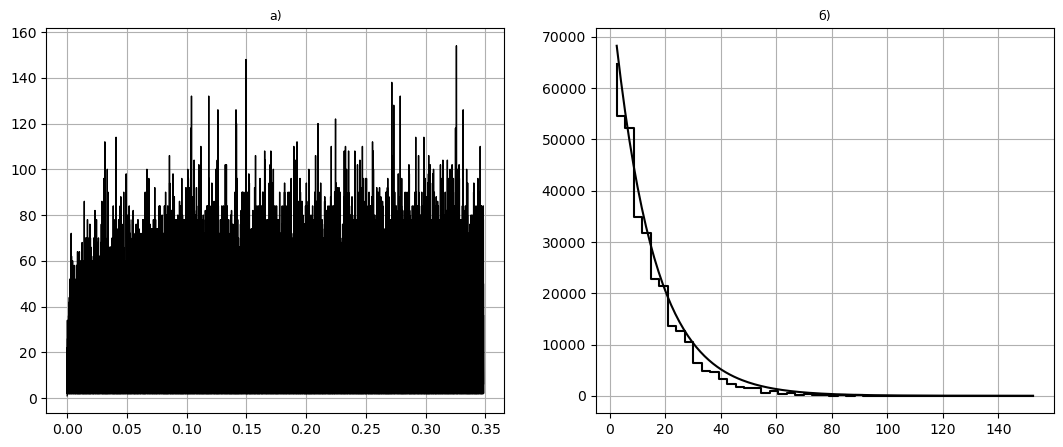

 a =  81259.92097515652  b =  0.06881547791293169


In [ ]:
# Ячейка № 15

# анализ свойств зависимостей
# первых разностей простых чисел
# порядкового номера вычитаемого
# простого числа

# нахождение простых чисел
# из диапазона [2; 5 * 10^6]
N = 5 * 10**6
Z = Eratosphen_out_Zeros(N)

# вычисление первых разностей
# простых чисел
d_Z = np.diff(Z)

# вычисление значения
# p порядка числа 10
# такого, что 10^p >= max(d_Z)
Power = Oder_of_Digit(len(d_Z))

# визуализация первых разностей
# простых чисел
F = plt.figure(figsize=(13, 11))
ax = F.add_subplot(2, 2, 1)

m = np.linspace(1, len(d_Z), len(d_Z))
plt.plot(m[:] / 10**Power, d_Z[:], "-k", lw=1)
ax.set_title("a)", fontsize=9)
plt.grid(True)

# вычисление эмпирической
# плотности распределения
# первых разностей простых чисел
H = np.histogram(d_Z, bins=50)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

# вычисление коэффициентов a, b, c
# аппроксимации эмпирической
# плотности распределения
# мгновенной  энергии демона
# функцией вида a * sqrt(-b * x)
Coeff = curve_fit(
    lambda t, a, b: a * np.exp(-b * t), x, H[0], bounds=(0, [len(d_Z), 8])
)
Сoeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a, b):
    return a * np.exp(-b * x)


# вычисление значений аппроксимирующей функции
x2 = np.linspace(x[0], x[len(x) - 1], 200)
y = func(x2, Сoeff2[0], Сoeff2[1])

# визуализация эмпирической плотности распределения
# и ее аппроксимации
ax = F.add_subplot(2, 2, 2)
plt.step(x, H[0], color="black")
plt.plot(x2, y, "-k")
plt.grid(True)
ax.set_title("б)", fontsize=9)
plt.show()
print(" a = ", Сoeff2[0], " b = ", Сoeff2[1])

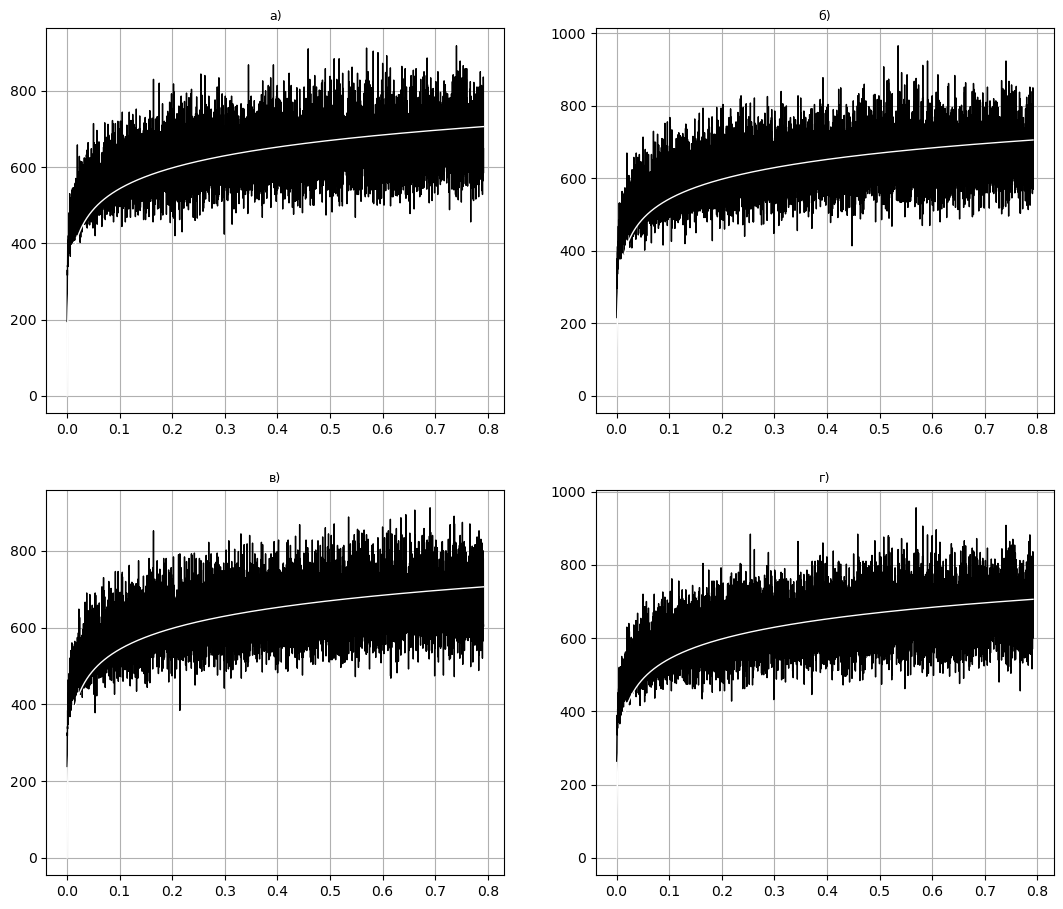

In [ ]:
# Ячейка № 16

# анализ статистических свойств
# первых разностей простых чисел,
# находящихся на выбранных P-спиралях

# вычисление первых разностей
# простых чисел, находящихся
# на P-спирали № 1
P_Number = 1
Z1 = Prime_Select(Z, P_Number)
d_Z1 = np.diff(Z1)

# задание массива, содержащего
# порядковые номера
# простых чисел, находящихся
# на P-спирали № 1
m = np.linspace(1, len(d_Z1), len(d_Z1))

# аппроксимация зависимости
# первых разностей простых чисел,
# находящихся на P-спирали № 1, от
# их порядкового номера
param, param_cov = curve_fit(lambda t, a: a * np.log(t), m, d_Z1)
Coeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a):
    return a * np.log(x)


# вычисление значений аппроксимирующей функции
y = func(m, param)

# вычисление значения
# p порядка числа 10
# такого, что 10^p >= max(d_Z1)
Power = Oder_of_Digit(len(d_Z1))

# визуализация зависимости
# первых разностей простых чисел,
# находящихся на Р-спирали № 1
#  от их порядкового номера и
# ее аппроксимации
F = plt.figure(figsize=(13, 11))
ax = F.add_subplot(2, 2, 1)
plt.plot(m[:] / 10**Power, d_Z1[:], "-k", lw=1)
plt.plot(m[:] / 10**Power, y, "-w", lw=1)
ax.set_title("a)", fontsize=9)
plt.grid(True)

# вычисление первых разностей
# простых чисел, находящихся
# на P-спирали № 5
P_Number = 5
Z1 = Prime_Select(Z, P_Number)
d_Z1 = np.diff(Z1)

# задание массива, содержащего
# порядковые номера
# простых чисел, находящихся
# на P-спирали № 1
m = np.linspace(1, len(d_Z1), len(d_Z1))

# аппроксимация зависимости
# первых разностей простых чисел,
# находящихся на P-спирали № 5, от
# их порядкового номера
param, param_cov = curve_fit(lambda t, a: a * np.log(t), m, d_Z1)
Coeff2 = Coeff[0]
# вычисление значений аппроксимирующей функции
y = func(m, param)

# визуализация зависимости
# первых разностей простых чисел,
# находящихся на Р-спирали № 5
#  от их порядкового номера и
# ее аппроксимации
ax = F.add_subplot(2, 2, 2)
plt.plot(m[:] / 10**Power, d_Z1[:], "-k", lw=1)
plt.plot(m[:] / 10**Power, y, "-w", lw=1)
ax.set_title("б)", fontsize=9)
plt.grid(True)

# вычисление первых разностей
# простых чисел, находяшихся
# на P-спирали № 22
P_Number = 22
Z1 = Prime_Select(Z, P_Number)
d_Z1 = np.diff(Z1)

# задание массива, содержащего
# порядковые номера
# простых чисел, находящихся
# на P-спирали № 22
m = np.linspace(1, len(d_Z1), len(d_Z1))

# аппроксимация зависимости
# первых разностей простых чисел,
# находящихся на P-спирали № 22, от
# их порядкового номера
param, param_cov = curve_fit(lambda t, a: a * np.log(t), m, d_Z1)
Coeff2 = Coeff[0]
# вычисление значений аппроксимирующей функции
y = func(m, param)

# визуализация зависимости
# первых разностей простых чисел,
# находящихся на Р-спирали № 22
#  от их порядкового номера и
# ее аппроксимации
ax = F.add_subplot(2, 2, 3)
plt.plot(m[:] / 10**Power, d_Z1[:], "-k", lw=1)
plt.plot(m[:] / 10**Power, y, "-w", lw=1)
ax.set_title("в)", fontsize=9)
plt.grid(True)

# вычисление первых разностей
# простых чисел, находяшихся
# на P-спирали № 44
P_Number = 44
Z1 = Prime_Select(Z, P_Number)
d_Z1 = np.diff(Z1)

# задание массива, содержащего
# порядковые номера
# простых чисел, находящихся
# на P-спирали № 44
m = np.linspace(1, len(d_Z1), len(d_Z1))

# аппроксимация зависимости
# первых разностей простых чисел,
# находящихся на P-спирали № 44, от
# их порядкового номера
param, param_cov = curve_fit(lambda t, a: a * np.log(t), m, d_Z1)
Coeff2 = Coeff[0]

# вычисление значений аппроксимирующей функции
y = func(m, param)

# визуализация зависимости
# первых разностей простых чисел,
# находящихся на Р-спирали № 44
#  от их порядкового номера и
# ее аппроксимации
ax = F.add_subplot(2, 2, 4)
m = np.linspace(1, len(d_Z1), len(d_Z1))
plt.plot(m[:] / 10**Power, d_Z1[:], "-k", lw=1)
plt.plot(m[:] / 10**Power, y, "-w", lw=1)
ax.set_title("г)", fontsize=9)

plt.grid(True)